# ch07 LMCache — RTX PRO 6000 Blackwell (GPU 1)

## 이 실습의 목표

vLLM 은 이미 **GPU 위에 prefix cache** 를 갖고 있다. 그러니 이건 "캐시 있음 vs 없음" 이 아니라 **"GPU 캐시만" vs "GPU 캐시 + LMCache CPU 계층"** 의 비교다. 
워킹셋이 GPU KV 예산을 넘겨서 축출이 일어날 때만 LMCache 가 이긴다.

| | |
|---|---|
| 프롬프트 30개 x 약 26k 토큰 | Qwen3-14B 는 토큰당 KV 약 160 KiB (40층 x KV헤드 8 x 128 x 2 x 2B) |
| 워킹셋 | 약 **125 GB** |
| GPU KV 예산 | 96GB x 0.90 - 27.5GB(가중치) = 약 **58 GB** |

워킹셋 > GPU 예산 이라 두 번째 순회에서 GPU 캐시는 축출된다. 이때 LMCache CPU 계층이 얼마나 건져내는지가 관전 포인트. 
**CPU 캐시를 125GB 미만으로 잡으면 warm 구간이 일부만 적중해서 LMCache 이득이 실제보다 작게 나온다** — `lmcache-setup.sh` 가 노드 RAM 기준으로 정하고 그 값을 출력한다.

## upstream 대비 변경

| 원본 | 여기 | 이유 |
|---|---|---|
| `lmcache==0.3.5`, `vllm==0.10.1` | setup.sh 의 vllm 0.27.1 + lmcache 0.5.x | 0.10.1 은 sm_120 커널이 없다 |
| `"kv_connector":"LMCacheConnectorV1"` | **`...V1Dynamic` + `kv_connector_module_path`** | vLLM 0.20+ 는 LMCache 패키지가 제공하는 커넥터를 동적 로드하는 쪽을 권장 |
| `LMCACHE_*` env 8개 | `LMCACHE_CONFIG_FILE=lmcache.yaml` | 현재 LMCache 문서 방식. 설정이 파일로 남아 증적이 된다 |
| `LMCACHE_MAX_LOCAL_CPU_SIZE=150.0` | 노드 RAM 의 40% (상한 150) | **pinned 메모리는 스왑이 안 된다.** 공용 노드에서 과하게 잡으면 남의 작업이 죽는다 |
| `pkill -f "vllm serve"` + `sleep 15` | `free_gpu(1)` | cmdline 매칭은 EngineCore 자식을 놓친다. VRAM 반납까지 조건 대기 |
| port 8000 | 8112 | SpecDecode(8111) 와 분리 |
| `--disable-log-requests` | 삭제 | vLLM ~0.19 에서 제거됨 |
| 결과 1파일 append + 행 순서로 구분 | 변형별 파일 | 한 번만 실패해도 그래프가 조용히 틀림 |
| 지연 측정값이 메모리에만 | `results/` 에 저장 | 커널이 죽으면 두 시간이 날아간다 |

## 실행 전
1. [setup.sh](setup.sh) 통과
2. [lmcache-setup.sh](lmcache-setup.sh) 통과 (0.6B 커넥터 스모크 포함)
3. `hf download Qwen/Qwen3-14B` 완료 (27.5 GiB)
4. GPU 1 비어 있음 — SpecDecode 서버가 남아 있으면 `free_gpu(1)` 먼저


In [2]:
!nvidia-smi

Sun Aug 23 16:09:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   33C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import os, sys, pathlib

# 커널이 setup.sh 가 만든 .venv 인지 확인. 아니면 뒤쪽 셀에서 엉뚱하게 터진다.
# python <=3.11 이면 flashinfer 가 import 시점에 죽는다 (array.array[int], CPython gh-98658).
assert sys.version_info >= (3, 12), (
    f"커널이 python {sys.version.split()[0]} 이다. VS Code 커널 피커에서 "
    "<workdir>/.venv/bin/python 을 선택할 것")
assert (pathlib.Path(sys.executable).parent.parent / "pyvenv.cfg").exists(), \
    f"커널이 venv 가 아니다: {sys.executable}"

# %%bash / subprocess 가 venv 의 vllm 을 찾게 한다. VS Code Jupyter 커널은
# sys.executable 만 venv 이고 PATH 는 아닌 경우가 많다 -> "vllm: command not found".
os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ["PATH"]

# torch import 보다 먼저 잡아야 먹는다.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # CUDA 인덱스 == nvidia-smi 인덱스
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# 미리 받아둔 모델을 쓰게 한다. 안 넣으면 vLLM 이 ~/.cache/huggingface 로 61GB 를 다시 받는다.
# 워크스페이스 *밖*(~/hf-cache)에 둔다 -- 작업 폴더를 지워도 모델은 살아남는다. 둘 다 밟은 실수다.
os.environ.setdefault("HF_HOME", str(pathlib.Path.home() / "hf-cache"))

PORT = 8112
RESULT_DIR = pathlib.Path("results"); RESULT_DIR.mkdir(exist_ok=True)

print(sys.executable)
!which vllm && vllm --version

/home/mlops/lm-cache/.venv/bin/python
/home/mlops/lm-cache/.venv/bin/vllm
0.27.1


In [4]:
import torch
from importlib.metadata import version

for p in ("vllm", "lmcache", "torch"):
    print(f"{p:8}", version(p))
print("device", torch.cuda.get_device_name(0), torch.cuda.get_device_capability(0))
assert torch.cuda.device_count() == 1, "CUDA_VISIBLE_DEVICES 미적용 -> 커널 재시작"

LMCACHE_YAML = pathlib.Path("lmcache.yaml")
assert LMCACHE_YAML.exists(), "lmcache.yaml 없음 -> ./lmcache-setup.sh 를 먼저 돌릴 것"
print("\n--- lmcache.yaml ---"); print(LMCACHE_YAML.read_text())

vllm     0.27.1
lmcache  0.5.4
torch    2.13.0+cu132
device NVIDIA RTX PRO 6000 Blackwell Server Edition (12, 0)

--- lmcache.yaml ---
# upstream 의 LMCACHE_* env 대신 YAML. 현재 LMCache 문서 방식이고,
# 설정이 파일로 남아 results/ 에 그대로 증적이 된다.
chunk_size: 256
local_cpu: true
max_local_cpu_size: 150



In [5]:
!nvidia-smi

Sun Aug 23 16:09:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   33C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os
import signal
import subprocess
import time
import requests
from collections import deque

def tail_log(filename, n=2):
    """Read and print the last n lines of a log file."""
    try:
        with open(filename, 'r') as f:
            last_lines = deque(f, maxlen=n)
        print(f"\n📜 Last {n} lines from {filename}:")
        for line in last_lines:
            print(line.rstrip())
    except FileNotFoundError:
        print(f"⚠️ Log file {filename} not found.")
    except Exception as e:
        print(f"⚠️ Error reading log file: {e}")

def check_vllm_status(logfile="vllm.log"):
    max_retries = 100
    wait_time = 10  # seconds  (32B 로딩 첫 회는 수 분)

    print("⏳ Waiting for vLLM server to become healthy...")

    for i in range(max_retries):
        try:
            r = requests.get(f"http://127.0.0.1:{PORT}/health")
            if r.ok:
                print("✅ vLLM server is healthy and ready!")
                tail_log(logfile, n=2)
                break
        except Exception:
            print(f"Attempt {i+1}: Not ready yet...")

        # Always print the last two lines of the log each iteration
        tail_log(logfile, n=2)

        time.sleep(wait_time)
    else:
        print("❌ Timed out waiting for vLLM server to start.")
        tail_log(logfile, n=2)


def _gpu_procs(gpu):
    """GPU 를 점유 중인 '내' PID 들. 공용 노드라 남의 프로세스는 절대 건드리지 않는다."""
    out = subprocess.run(
        ["nvidia-smi", "-i", str(gpu), "--query-compute-apps=pid", "--format=csv,noheader"],
        capture_output=True, text=True).stdout.split()
    mine = []
    for s in out:
        try:
            if os.stat(f"/proc/{int(s)}").st_uid == os.getuid():
                mine.append(int(s))
        except (ValueError, FileNotFoundError, ProcessLookupError):
            pass
    return mine


def _gpu_used(gpu):
    return subprocess.run(
        ["nvidia-smi", "-i", str(gpu), "--query-gpu=memory.used", "--format=csv,noheader"],
        capture_output=True, text=True).stdout.strip()


def free_gpu(gpu=1, timeout=180):
    """서버를 죽이고 VRAM 이 '실제로' 반납될 때까지 기다린다.

    sleep(N) 을 쓰지 않는 이유: 32B 는 61GB 반납이라 고정 대기로는 못 맞추고,
    덜 비워진 상태에서 다음 변형이 뜨면 OOM 으로 죽는다.
    pkill -f "vllm serve" 를 쓰지 않는 이유: EngineCore 자식은 cmdline 이 달라서
    매칭에 안 걸리고 그대로 살아남는다. GPU 가 알려주는 PID 를 직접 죽인다.
    """
    for sig in (signal.SIGTERM, signal.SIGKILL):
        for pid in _gpu_procs(gpu):
            try:
                os.kill(pid, sig)
            except ProcessLookupError:
                pass
        deadline = time.time() + (timeout if sig == signal.SIGTERM else 30)
        while time.time() < deadline:
            if not _gpu_procs(gpu):
                time.sleep(3)                     # 드라이버가 반납을 마칠 여유
                print(f"GPU{gpu} 정리 완료 (used={_gpu_used(gpu)})")
                return
            time.sleep(3)
        print(f"GPU{gpu} {sig.name} 으로 안 죽음")
    raise RuntimeError(f"GPU{gpu} 를 못 비웠다 (used={_gpu_used(gpu)}). 수동 확인 필요")


In [6]:
import json
from openai import OpenAI

MODEL = "Qwen/Qwen3-14B"
client = OpenAI(api_key="EMPTY", base_url=f"http://localhost:{PORT}/v1")


def timed_completion(prompt, max_tokens=10):
    t0 = time.time()
    client.completions.create(model=MODEL, prompt=prompt, max_tokens=max_tokens, temperature=0)
    return time.time() - t0


def latency_sweep(variant, n=30):
    """같은 프롬프트 30종을 두 바퀴. 1바퀴=cold(캐시 채우기), 2바퀴=warm(재사용).

    upstream 은 결과를 파이썬 리스트에만 담는데, 두 구성을 다 돌리려면 한 시간이 넘고
    그 사이 커널이 죽으면 전부 날아간다. 그래서 파일로 떨군다.
    """
    def prompts():
        for i in range(n):
            yield f"Hello this is now a brand new prompt, how are you? {i}" * 2000 + "Hello, my name is"

    out = {}
    for phase in ("cold", "warm"):
        ts = []
        for i, p in enumerate(prompts()):
            ts.append(timed_completion(p))
            print(f"  {variant} {phase} {i+1}/{n}: {ts[-1]:.2f}s", end="\r")
        out[phase] = ts
        print(f"\n  {variant} {phase}: 중앙값 {sorted(ts)[len(ts)//2]:.2f}s, 합계 {sum(ts):.1f}s")

    path = RESULT_DIR / f"latency-{variant}.json"
    path.write_text(json.dumps(out))
    print(f"  -> {path}")
    return out

In [7]:
import shlex, subprocess


def run_vllm_bench(variant, max_concurrency=1, num_prompts=20, num_prefixes=20,
                   prefix_len=40000, suffix_len=10, output_len=20, save=True):
    """prefix_repetition 데이터셋 — 외부 파일이 필요 없다 (생성형). Spec-Bench 와 다른 점."""
    result_filename = str(RESULT_DIR / f"bench-{variant}.json")
    cmd = f"""vllm bench serve --backend vllm
      --base-url http://localhost:{PORT} --endpoint /v1/completions
      --dataset-name prefix_repetition
      --prefix-repetition-num-prefixes {num_prefixes}
      --prefix-repetition-prefix-len {prefix_len}
      --prefix-repetition-suffix-len {suffix_len}
      --prefix-repetition-output-len {output_len}
      --num-prompts {num_prompts} --model {MODEL}
      --max-concurrency {max_concurrency}
      {"--save-result --append-result --result-filename " + result_filename if save else ""}"""
    print("Running:", " ".join(cmd.split()))
    proc = subprocess.Popen(shlex.split(" ".join(cmd.split())), stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    print(f"\nexit={proc.returncode}")
    return proc.returncode

def warmup_shapes(concurrency):
    """측정 밖에서 배치 shape 을 태운다. SpecDecode 에서 동시성을 올리는 순간
    Triton `_topk_topp_kernel` 이 추론 중 JIT 컴파일되며 TTFT 에 3.3초 스파이크가 찍혔다.

    prefix_repetition 을 워밍업에 쓰면 안 된다 -- seed 가 고정이라 본 측정과 **같은**
    프롬프트를 미리 캐시에 올려서 뒤따르는 cold 를 cold 가 아니게 만든다.
    문제의 커널은 배치 크기로 키가 잡히므로, 짧은 random 프롬프트로 shape 만 밟는다.
    """
    cmd = f"""vllm bench serve --backend vllm
      --base-url http://localhost:{PORT} --endpoint /v1/completions --model {MODEL}
      --dataset-name random --random-input-len 128 --random-output-len 16
      --num-prompts {concurrency} --max-concurrency {concurrency}"""
    r = subprocess.run(shlex.split(" ".join(cmd.split())), capture_output=True, text=True)
    ok = "Serving Benchmark Result" in r.stdout
    print(f"[warmup] concurrency={concurrency}: {'ok' if ok else 'FAILED'}")
    if not ok:
        print(r.stdout[-1500:] or r.stderr[-1500:])


def bench_triplet(variant):
    """cold -> warm -> warm concurrent. 순서가 의미를 만든다 (1회차가 캐시를 채운다)."""
    for conc in (1, 5):
        warmup_shapes(conc)
    run_vllm_bench(variant, max_concurrency=1)   # cold
    run_vllm_bench(variant, max_concurrency=1)   # warm
    run_vllm_bench(variant, max_concurrency=5)   # warm concurrent

# 1. LMCache 켜고

In [9]:
!nvidia-smi

Sun Aug 23 16:10:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   33C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
free_gpu(1)
!rm -f results/bench-lmcache.json   # append 되므로 새로 시작할 땐 지운다

GPU1 정리 완료 (used=3 MiB)


In [12]:
%%bash
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1
export HF_HOME="$HOME/hf-cache"
# PYTHONHASHSEED: LMCache 가 파이썬 builtin hash 로 토큰 청크 키를 만든다.
# 시드가 프로세스마다 다르면 EngineCore 재기동 후 같은 프롬프트가 다른 키가 되어
# 캐시를 조용히 못 찾는다 -> "LMCache 이득 없음" 이라는 틀린 결과가 나온다.
export PYTHONHASHSEED=0
export LMCACHE_CONFIG_FILE="$PWD/lmcache.yaml"

nohup vllm serve Qwen/Qwen3-14B \
  --kv-transfer-config '{"kv_connector":"LMCacheConnectorV1Dynamic","kv_role":"kv_both","kv_connector_module_path":"lmcache.integration.vllm.lmcache_connector_v1"}' \
  --port 8112 \
  --max-model-len 40960 \
  --gpu-memory-utilization 0.90 \
  > vllm-lmcache.log 2>&1 &
echo "launched -> vllm-lmcache.log"


launched -> vllm-lmcache.log


In [13]:
check_vllm_status("vllm-lmcache.log")

# 커넥터가 실제로 붙었는지. 여기서 안 보이면 아래 측정은 의미가 없다.
!grep -iE "lmcache|kv_connector" vllm-lmcache.log | tail -5

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-lmcache.log:
(APIServer pid=3062373) INFO 08-23 16:10:24 [api_utils.py:273] non-default args: {'model_tag': 'Qwen/Qwen3-14B', 'port': 8112, 'model': 'Qwen/Qwen3-14B', 'max_model_len': 40960, 'gpu_memory_utilization': 0.9, 'kv_transfer_config': KVTransferConfig(kv_connector='LMCacheConnectorV1Dynamic', engine_id='ecb60395-e8b8-42b8-95e0-2ca5516eb75e', kv_buffer_device='cuda', kv_buffer_size=1000000000.0, kv_role='kv_both', kv_rank=None, kv_parallel_size=1, kv_ip='127.0.0.1', kv_port=14579, kv_connector_extra_config={}, kv_connector_module_path='lmcache.integration.vllm.lmcache_connector_v1', enable_permute_local_kv=False, kv_load_failure_policy='fail')}
(APIServer pid=3062373) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm-lmcache.log:
(APIServe

In [14]:
# 커넥터가 실제로 붙었는지. 여기서 안 보이면 아래 측정은 의미가 없다.
!grep -iE "lmcache|kv_connector" vllm-lmcache.log | tail -5

(EngineCore pid=3063453) [2026-08-23 16:11:17,925] LMCache WARNING: Could not load 'builtin' from vLLM. Using builtin hash. This may cause inconsistencies in distributed caching. (token_database.py:162:lmcache.v1.token_database)
(EngineCore pid=3063453) [2026-08-23 16:11:17,925] LMCache INFO: Initialized NONE_HASH=5313149338359954478 from vLLM (>= PR#20511) (token_database.py:100:lmcache.v1.token_database)
(EngineCore pid=3063453) [2026-08-23 16:11:17,925] LMCache INFO: Using hash algorithm: builtin (token_database.py:110:lmcache.v1.token_database)
(EngineCore pid=3063453) [2026-08-23 16:11:17,926] LMCache INFO: Internal API server disabled. internal_api_server_enabled=False, port_offset=0, port=6999, socket_path=None, include_index_list=None (api_server.py:67:lmcache.v1.internal_api_server.api_server)
(EngineCore pid=3063453) [2026-08-23 16:11:17,926] LMCache INFO: LMCache initialized for role KVConnectorRole.SCHEDULER with version 0.5.4-g3e11b8ed, vllm version 0.27.1, lmcache cache_e

In [15]:
lat_lmcache = latency_sweep("lmcache")

  lmcache cold 30/30: 4.08s
  lmcache cold: 중앙값 4.05s, 합계 118.5s
  lmcache warm 30/30: 0.38s
  lmcache warm: 중앙값 0.37s, 합계 11.1s
  -> results/latency-lmcache.json


In [16]:
bench_triplet("lmcache")

[warmup] concurrency=1: ok
[warmup] concurrency=5: ok
Running: vllm bench serve --backend vllm --base-url http://localhost:8112 --endpoint /v1/completions --dataset-name prefix_repetition --prefix-repetition-num-prefixes 20 --prefix-repetition-prefix-len 40000 --prefix-repetition-suffix-len 10 --prefix-repetition-output-len 20 --num-prompts 20 --model Qwen/Qwen3-14B --max-concurrency 1 --save-result --append-result --result-filename results/bench-lmcache.json
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7efb3bf19a80>, trust_remote_code=False, seed=0, num_prompts=20, dataset_name='prefix_repetition', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegp

In [17]:
!grep -oE "hit tokens: [0-9]+, need to load: [0-9]+" vllm-lmcache.log | tail -25

hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936
hit tokens: 39936, need to load: 39936


In [18]:
!grep -oE "Prefix cache hit rate: [0-9.]+%" vllm-lmcache.log | tail -5

Prefix cache hit rate: 0.0%
Prefix cache hit rate: 0.0%
Prefix cache hit rate: 0.0%
Prefix cache hit rate: 0.0%
Prefix cache hit rate: 0.0%


# 2. Vanilla vLLM (GPU prefix cache 만)

In [8]:
free_gpu(1)
!rm -f results/bench-vanilla.json

GPU1 정리 완료 (used=3 MiB)


In [9]:
!nvidia-smi

Sun Aug 23 16:27:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   32C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
%%bash
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1
export HF_HOME="$HOME/hf-cache"

nohup vllm serve Qwen/Qwen3-14B \
  --port 8112 \
  --max-model-len 40960 \
  --gpu-memory-utilization 0.90 \
  > vllm-vanilla.log 2>&1 &
echo "launched -> vllm-vanilla.log"


launched -> vllm-vanilla.log


In [13]:
check_vllm_status("vllm-vanilla.log")

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-vanilla.log:
(EngineCore pid=3126048) INFO 08-23 16:28:02 [jit_monitor.py:79] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=3126048) INFO 08-23 16:28:02 [core.py:348] init engine (profile, create kv cache, warmup model) took 8.65 s (compilation: 0.12 s)
✅ vLLM server is healthy and ready!

📜 Last 2 lines from vllm-vanilla.log:
(APIServer pid=3125232) INFO 08-23 16:28:10 [launcher.py:105] API server: HTTP server started
(APIServer pid=3125232) INFO:     127.0.0.1:33264 - "GET /health HTTP/1.1" 200 OK


In [14]:
lat_vanilla = latency_sweep("vanilla")

  vanilla cold 30/30: 3.96s
  vanilla cold: 중앙값 3.93s, 합계 115.1s
  vanilla warm 30/30: 3.96s
  vanilla warm: 중앙값 3.94s, 합계 115.5s
  -> results/latency-vanilla.json


In [15]:
bench_triplet("vanilla")

[warmup] concurrency=1: ok
[warmup] concurrency=5: ok
Running: vllm bench serve --backend vllm --base-url http://localhost:8112 --endpoint /v1/completions --dataset-name prefix_repetition --prefix-repetition-num-prefixes 20 --prefix-repetition-prefix-len 40000 --prefix-repetition-suffix-len 10 --prefix-repetition-output-len 20 --num-prompts 20 --model Qwen/Qwen3-14B --max-concurrency 1 --save-result --append-result --result-filename results/bench-vanilla.json
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f7c28b359e0>, trust_remote_code=False, seed=0, num_prompts=20, dataset_name='prefix_repetition', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegp

# 3. 정리 / teardown

In [16]:
# dmon 로그도 여기서 Ctrl-C
free_gpu(1)

GPU1 정리 완료 (used=3 MiB)


In [17]:
!nvidia-smi

Sun Aug 23 16:42:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   32C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# 4. 그래프

/tmp/ipykernel_3112838/4154879005.py:16: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3112838/4154879005.py:16: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3112838/4154879005.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3112838/4154879005.py:16: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3112838/4154879005.py:16: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/mlops/lm-cache/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

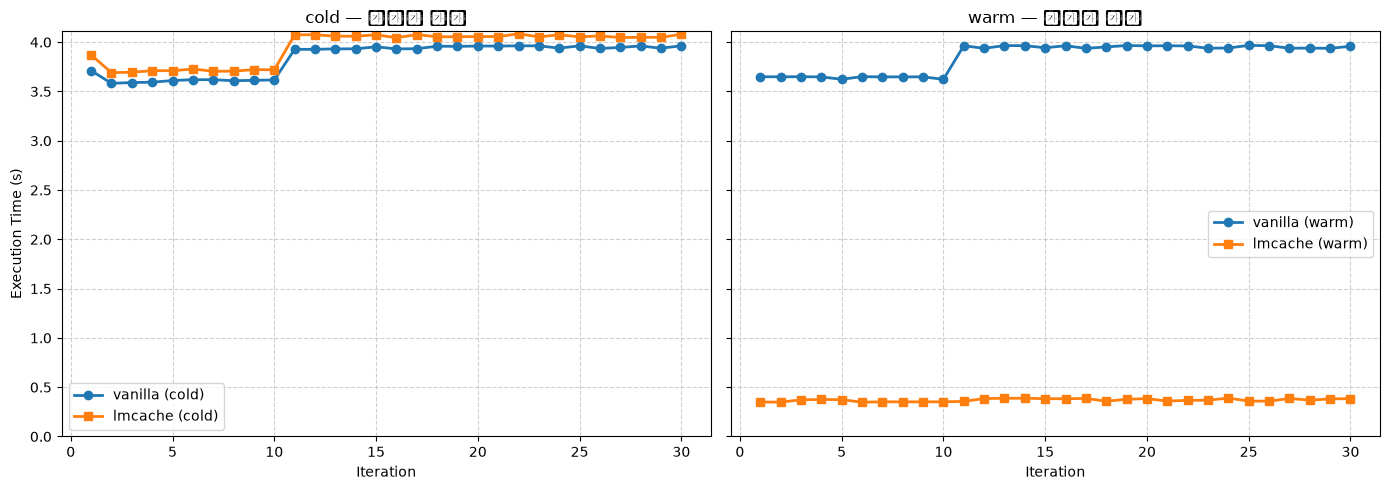

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 파일에서 읽는다 -> 커널을 재시작했거나 두 구성을 다른 날 돌렸어도 그린다.
lat = {v: json.loads((RESULT_DIR / f"latency-{v}.json").read_text())
       for v in ("lmcache", "vanilla")}

# 서버에 한글 폰트가 없다 -> 라벨은 ASCII 로. (폰트 설치보다 이게 싸다)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, phase in zip(axes, ("cold", "warm")):
    for v, marker in (("vanilla", "o"), ("lmcache", "s")):
        y = lat[v][phase]
        ax.plot(np.arange(1, len(y) + 1), y, marker=marker, linewidth=2, label=f"{v} ({phase})")
    ax.set_xlabel("Iteration"); ax.set_title(f"{phase} - per-request latency")
    ax.grid(True, linestyle="--", alpha=0.6); ax.legend(); ax.set_ylim(bottom=0)
axes[0].set_ylabel("Execution Time (s)")
plt.tight_layout(); plt.savefig(RESULT_DIR / "latency.png", dpi=120); plt.show()

# 그림에서 눈대중하지 말고 숫자로
for v in ("vanilla", "lmcache"):
    c, w = sorted(lat[v]["cold"]), sorted(lat[v]["warm"])
    print(f"{v:8} cold 중앙값 {c[len(c)//2]:.2f}s  warm 중앙값 {w[len(w)//2]:.2f}s  "
          f"warm 배속 {c[len(c)//2]/w[len(w)//2]:.1f}x")
print(f"\nwarm 구간 lmcache vs vanilla: "
      f"{sorted(lat['vanilla']['warm'])[15] / sorted(lat['lmcache']['warm'])[15]:.1f}x")

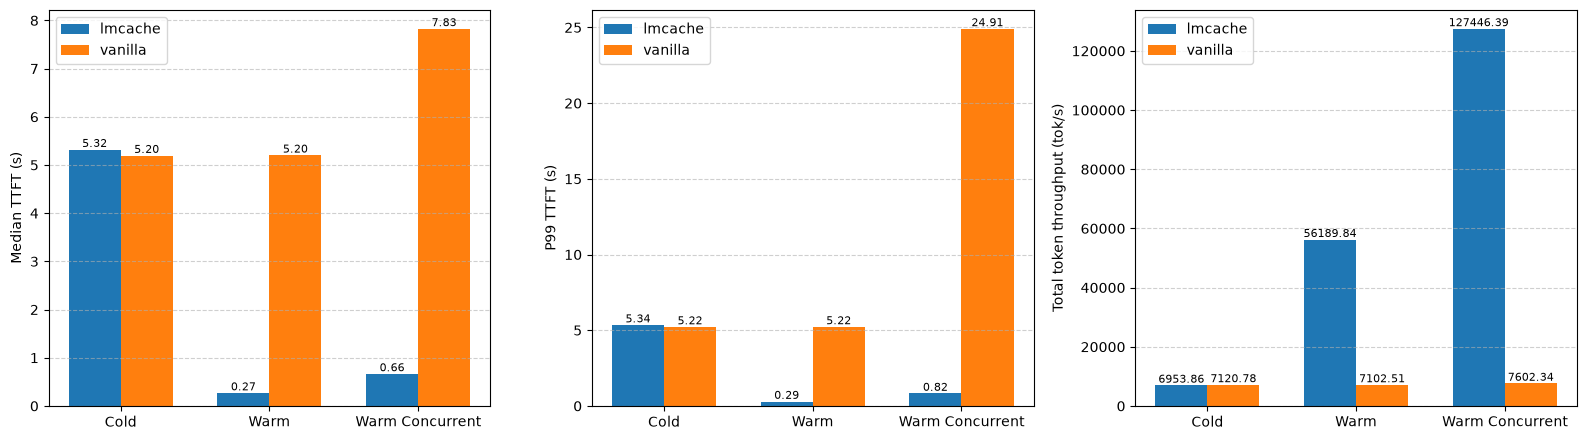

In [19]:
# 벤치 3종(cold / warm / warm concurrent) 비교.
# 원본은 한 파일의 행 순서로 6개를 구분했다 -> 변형별 파일에서 마지막 3줄만 읽는다.
LABELS = ["Cold", "Warm", "Warm Concurrent"]
rows = {}
for v in ("lmcache", "vanilla"):
    lines = [json.loads(l) for l in open(RESULT_DIR / f"bench-{v}.json") if l.strip()]
    assert len(lines) >= 3, f"{v}: 벤치 3회가 필요한데 {len(lines)}줄"
    rows[v] = lines[-3:]

METRICS = [("median_ttft_ms", "Median TTFT (s)", 1000),
           ("p99_ttft_ms", "P99 TTFT (s)", 1000),
           ("total_token_throughput", "Total token throughput (tok/s)", 1)]

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 4.5))
x, w = np.arange(len(LABELS)), 0.35
for ax, (key, ylabel, scale) in zip(axes, METRICS):
    for off, v in ((-w/2, "lmcache"), (w/2, "vanilla")):
        vals = [r[key] / scale for r in rows[v]]
        ax.bar(x + off, vals, w, label=v)
        for px, val in zip(x + off, vals):
            ax.text(px, val, f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.6); ax.legend()
plt.tight_layout(); plt.show()